# Seed based functional connectivity

In [1]:
import nilearn as nil
import nibabel as nib
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from nilearn import plotting, surface, datasets
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm # For having progressbar during loops
from nitime.timeseries import TimeSeries
from nitime.analysis import FilterAnalyzer

# Load an example  subject

In [2]:
# main_path='E:/CorsoFisica/rest_STD/' # Path to the folder with the subjects
# main_path='C:/Unito/PhD/CorsoFisica/data/rest_STD/' # Path to the folder with the subjects - without denoising
main_path='C:/Unito/PhD/CorsoFisica/data/rest_STD_clean/' # Path to the folder with the subjects - with denoising

filelist = os.listdir(main_path) # List of the subjects

sub_ = nib.load(main_path+filelist[0]) # Load the nii.gz file of the subject
sub_header = sub_.header # Subject's header
sub_affine = sub_.affine # Subject's affine
sub = sub_.get_fdata() # Get the numpy version of the nii.gz file
print(sub.shape) # x*y*z*time

(52, 62, 52, 356)


# Load the brain mask

In [3]:
main_path='C:/Unito/PhD/CorsoFisica/data/group_mask/' # Path to the folder with the brain mask
filename='group_mask.nii.gz' # List of the subjects

mask_ = nib.load(main_path+filename) # Load the nii.gz file of the subject
mask_header = mask_.header # Subject's header
mask_affine = mask_.affine # Subject's affine
mask = mask_.get_fdata() # Get the numpy version of the nii.gz file
print(mask.shape) # x*y*z*time
n_vox_mask = np.sum(mask==1) # Number of voxels within the mask

(52, 62, 52)


# Load the atlas
In order to define regions of the brain, we need an atlas

In [4]:
which_atlas = 'glasser' # Chose the atlas
main_path='C:/Unito/PhD/CorsoFisica/data/atlas/' # Path to the folder with the atlas
filename = 'glasser_MNI152NLin6Asym_labels_p20_resamp.nii.gz'
atlas_labels_file = 'glasser_labels.csv'
delimiter = ','

atlas_ = nib.load(main_path+'/'+which_atlas+'/'+filename) # Load the nii.gz file of the subject
atlas_header = atlas_.header # Subject's header
atlas_affine = atlas_.affine # Subject's affine
atlas = atlas_.get_fdata() # Get the numpy version of the nii.gz file
print(atlas.shape) # x*y*z*time

# Labels
atlas_labels = pd.read_csv(main_path+'/'+which_atlas+'/'+atlas_labels_file, delimiter=delimiter)
print(atlas.min(), atlas.max())

(52, 62, 52)
0.0 360.0


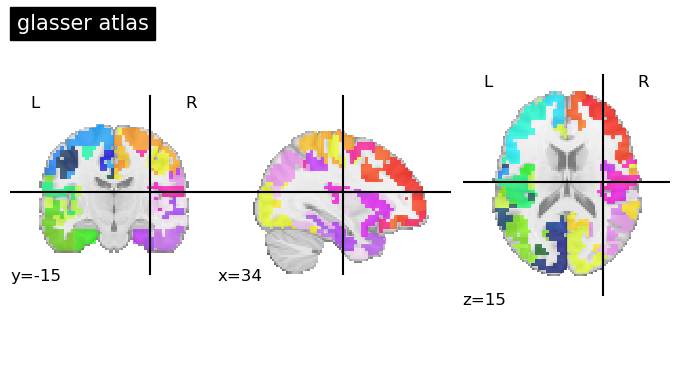

In [5]:
# Plot the atlas
plotting.plot_roi(atlas_, title=which_atlas+' atlas', display_mode='ortho')

In [6]:
# Subdivision in cortices of the glasser atlas
network_list = atlas_labels['cortex'].unique().tolist()
# network_list

# Exploring the functional connectivity of the motor cortex
Chose the motor cortex of one of the two emisphere as the seed area for the seed-based functional connectivity analysis

### Define the seed area

In [7]:
seed_areas = atlas_labels.loc[atlas_labels['regionLongName']=='Primary_Motor_Cortex_L']
seed_idxs = seed_areas['regionID'].values # Indexes of the seed areas
seed_areas

,regionName,regionLongName,regionIdLabel,LR,region,Lobe,cortex,regionID,Cortex_ID,x-cog,y-cog,z-cog,volmm
7,4_L,Primary_Motor_Cortex_L,8_L,L,4,Fr,Somatosensory_and_Motor,8,6,119.338359,105.485002,126.65561,6301


In [8]:
# Create a brain mask of our seed region
seeds_mask = np.zeros(atlas.shape)
for seed in seed_idxs:
    seeds_mask += (atlas==seed)

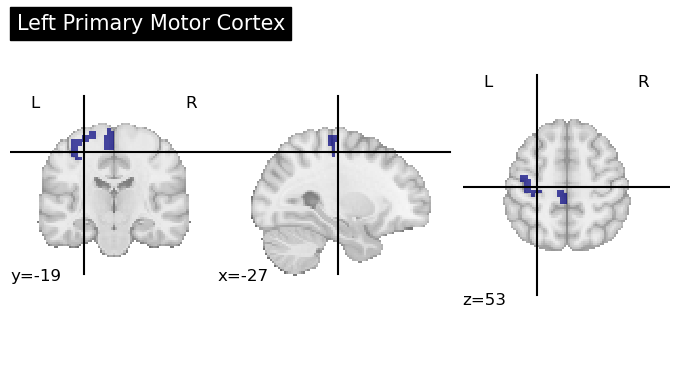

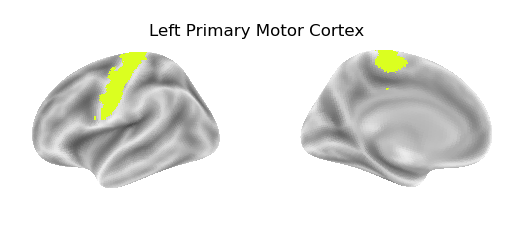

In [9]:
## Plot the seed region

# Plot over the volume of the brain
seeds_img = nib.Nifti1Image(seeds_mask.astype(np.int16), atlas_affine) # Create a new image for the selected region
plotting.plot_roi(seeds_img, display_mode='ortho', title='Left Primary Motor Cortex')
plotting.show()

# Plot over the surface of the brain ##
fsaverage = datasets.fetch_surf_fsaverage()
texture_left = surface.vol_to_surf(seeds_img, fsaverage.pial_left)
texture_left[np.where(texture_left!=0)] = 1

fig, axs = plt.subplots(1,2, subplot_kw={'projection': '3d'})
# left hemisphere
plotting.plot_surf_roi(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       colorbar=False, view='lateral',axes=axs[0])
plotting.plot_surf_roi(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       colorbar=False, view='medial', axes=axs[1])
fig.suptitle('Left Primary Motor Cortex', x=0.51, y=0.7)

plotting.show()

# Compute the whole brain functional connectivity map for the seed region

## At first, compute the average time series of the seed region

In [10]:
# Apply the seed's mask to the whole brain, then average the time series of the voxels within the seed, in order
# to obtain the time series off the whole seed
seed_voxels = sub[seeds_mask==1]
print(seed_voxels.shape)
seed_ts = seed_voxels.mean(axis=0)
print(seed_ts.shape)

(250, 356)
(356,)


We are assuming an isotropy of the signal inside the seed region...

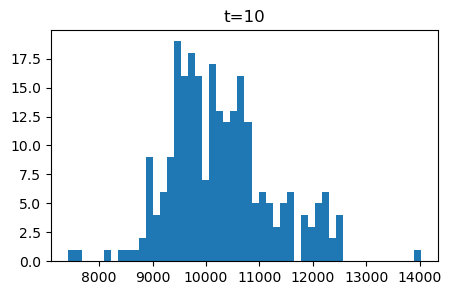

In [11]:
# Let's check the distribution of the activity values of the voxels inside the seed region
t = 10 # choose a time point
fig = plt.figure(figsize=(5,3))
plt.hist(seed_voxels[:,t], bins=50);
plt.title('t='+str(t));

Text(0.5, 1.0, "Average seed's time series")

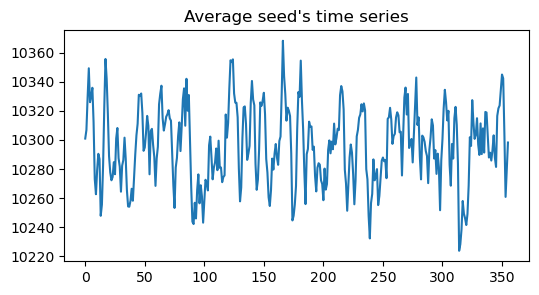

In [12]:
# Visualize the average time series of the seed region
fig = plt.figure(figsize=(6,3))
plt.plot(seed_ts);
plt.title("Average seed's time series")
# plt.xlim(0,20)

## Correlate the time series of the seed with all the other voxels of the brain

In [13]:
# At first, choose the coorrelation measure
corr_measure = pearsonr
# corr_measure = spearmanr

fcmap = np.empty(mask.shape) # Initialize the functional connectivity map
fcmap_p = np.empty(mask.shape) # p-values related the correlation measure
mask_cord = np.where(mask==1) # Coordinates of all the voxel within the brain mask

# Loop over all the voxel of the brain
for v in tqdm(range(n_vox_mask)):
    voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    corr = corr_measure(seed_ts, voxel_ts)
    fcmap[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[0]
    fcmap_p[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[1]


100%|████████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [01:04<00:00, 778.78it/s]


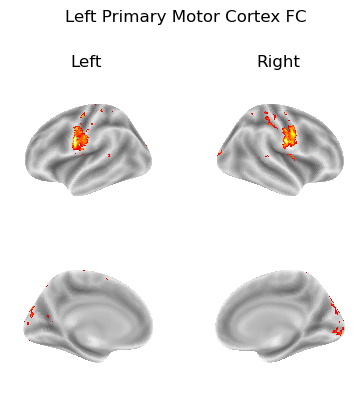

In [14]:
# Plot the FC maps
# threshold the Fc maps with the pvalues 
fcmap_thresholded = np.copy(fcmap)
fcmap_thresholded[np.where(fcmap_p>0.001/n_vox_mask)] = 0

fsaverage = datasets.fetch_surf_fsaverage()
fcmap_img = nib.Nifti1Image(fcmap_thresholded, sub_affine)
texture_left = surface.vol_to_surf(fcmap_img, fsaverage.pial_left)
texture_right = surface.vol_to_surf(fcmap_img, fsaverage.pial_right)

thresh = 0.2 # Threshold for the brain plots

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, figsize=(4,4))
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       title='Left', view='lateral',colorbar=False, threshold=thresh, axes=axs[0][0])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                       title='Right', view='lateral', colorbar=False, threshold=thresh, axes=axs[0][1])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][0])
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][1])
fig.suptitle('Left Primary Motor Cortex FC', x=0.51, y=1)
plt.tight_layout()
plotting.show()

## Try to clean the signal before the fc analysis

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 50.62it/s]


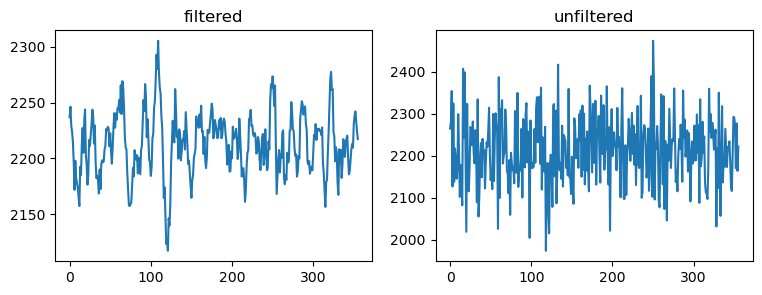

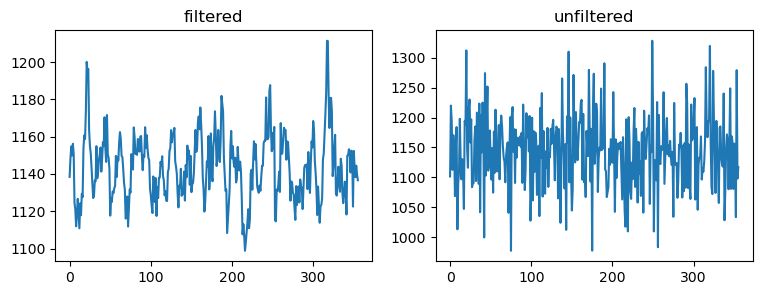

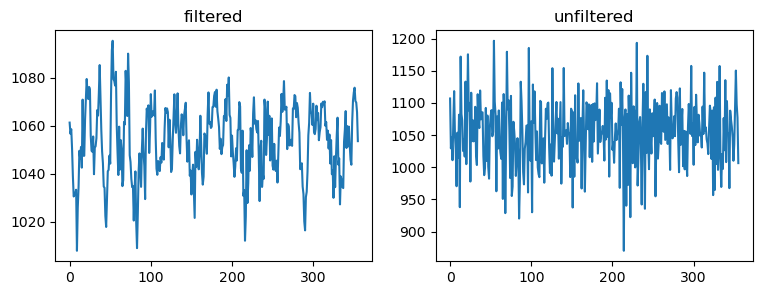

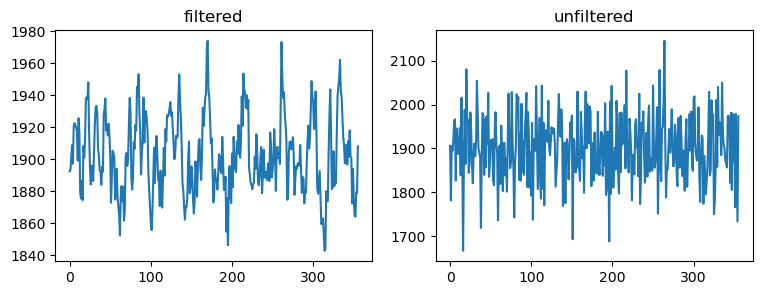

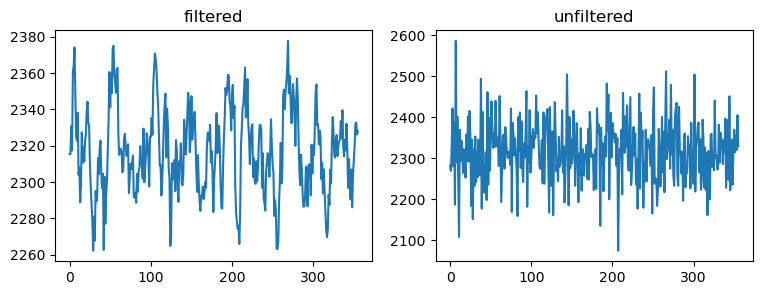

In [15]:
# An example of filtering with a bandpass filter
sub_filtered = np.copy(sub)
TR = sub_.header.get_zooms()[3]
for v in tqdm(range(15,20)):
    voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    T = TimeSeries(voxel_ts.T, sampling_interval=TR)
    F = FilterAnalyzer(T, ub=0.08, lb=0.008) #0.08, 0.008
    tmp_TC_filt = F.filtered_boxcar.data
    tmp_TC_filt = tmp_TC_filt.T
    sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt
    fig,axs = plt.subplots(1,2, figsize=(9,3))
    axs[0].plot(tmp_TC_filt, alpha=1)
    axs[0].set_title('filtered')
    axs[1].plot(voxel_ts, alpha=1)
    axs[1].set_title('unfiltered')


In [16]:
# Filter an entire subject
sub_filtered = np.copy(sub)
TR = sub_.header.get_zooms()[3]
for v in tqdm(range(n_vox_mask)):
    voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    T = TimeSeries(voxel_ts.T, sampling_interval=TR)
    F = FilterAnalyzer(T, ub=0.08, lb=0.008) #0.08, 0.008
    tmp_TC_filt = F.filtered_boxcar.data
    tmp_TC_filt = tmp_TC_filt.T
    sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt
#     plt.plot(tmp_TC_filt, label='filtered', alpha=0.75)
#     plt.plot(voxel_ts, label='original', alpha=0.75)
#     plt.legend()

100%|███████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [00:12<00:00, 3890.56it/s]


In [17]:
# Now perform the analysis with the filtered subject

# Extract the time series of the seed region
seed_voxels = sub_filtered[seeds_mask==1]
seed_ts = seed_voxels.mean(axis=0)

# At first, choose the coorrelation measure
corr_measure = pearsonr
# corr_measure = spearmanr

fcmap = np.empty(mask.shape) # Initialize the functional connectivity map
fcmap_p = np.empty(mask.shape) # p-values related the correlation measure
mask_cord = np.where(mask==1) # Coordinates of all the voxel within the brain mask

## Correlation ##
# Loop over all the voxel of the brain
for v in tqdm(range(n_vox_mask)):
    voxel_ts = sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    corr = corr_measure(seed_ts, voxel_ts)
    fcmap[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[0]
    fcmap_p[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[1]

100%|████████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [01:08<00:00, 727.32it/s]


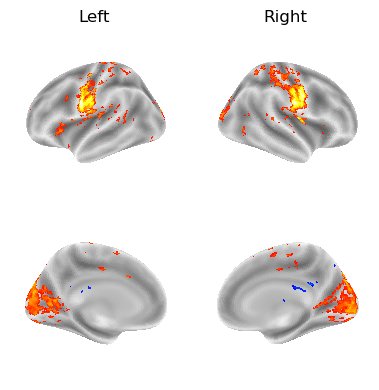

In [18]:
# Plot the FC map
# threshold the FC map with the pvalues 
fcmap_thresholded = np.copy(fcmap)
fcmap_thresholded[np.where(fcmap_p>0.001/n_vox_mask)] = 0

fsaverage = datasets.fetch_surf_fsaverage()
fcmap_img = nib.Nifti1Image(fcmap_thresholded, sub_affine)
texture_left = surface.vol_to_surf(fcmap_img, fsaverage.pial_left)
texture_right = surface.vol_to_surf(fcmap_img, fsaverage.pial_right)

thresh = 0.3 # Threshold for the brain plots

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, figsize=(4,4))
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       title='Left', view='lateral',colorbar=False, threshold=thresh, axes=axs[0][0])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                       title='Right', view='lateral', colorbar=False, threshold=thresh, axes=axs[0][1])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][0])
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][1])
plt.tight_layout()
plotting.show()

# Compute the functional connectivity of out seed region for many subjects

In [19]:
main_path='C:/Unito/PhD/CorsoFisica/data/rest_STD_clean/' # Path to the folder with the subjects

# At first, choose the coorrelation measure
corr_measure = pearsonr
# corr_measure = spearmanr
mask_cord = np.where(mask==1) # Coordinates of all the voxel within the brain mask


fcmap_allsub = np.empty(mask.shape)[np.newaxis,:,:,:]
fcmap_p_allsub = np.empty(mask.shape)[np.newaxis,:,:,:]

# Loop over the subjects
for sub_file in filelist:
    print(sub_file)
    sub_ = nib.load(main_path+sub_file) # Load the nii.gz file of the subject
    sub_header = sub_.header # Subject's header
    sub_affine = sub_.affine # Subject's affine
    sub = sub_.get_fdata() # Get the numpy version of the nii.gz file
    
    # Filter the signal
    sub_filtered = np.copy(sub)
    TR = sub_.header.get_zooms()[3]
    print('Filtering the signal...')
    for v in tqdm(range(n_vox_mask)):
        voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
        T = TimeSeries(voxel_ts.T, sampling_interval=TR)
        F = FilterAnalyzer(T, ub=0.08, lb=0.008) #0.08, 0.008
        tmp_TC_filt = F.filtered_boxcar.data
        tmp_TC_filt = tmp_TC_filt.T
        sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt

    # Compute the average time series of the seed region
    seed_voxels = sub_filtered[seeds_mask==1]
    seed_ts = seed_voxels.mean(axis=0)

    fcmap = np.empty(mask.shape) # Initialize the functional connectivity map
    fcmap_p = np.empty(mask.shape) # p-values related the correlation measure

    # Loop over all the voxel of the brain
    print('Computing the correlation...')
    for v in tqdm(range(n_vox_mask)):
        voxel_ts = sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
        corr = corr_measure(seed_ts, voxel_ts)
        fcmap[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[0]
        fcmap_p[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[1]
    
    fcmap_allsub = np.concatenate((fcmap_allsub, fcmap[np.newaxis,:,:,:]))
    fcmap_p_allsub = np.concatenate((fcmap_p_allsub, fcmap_p[np.newaxis,:,:,:]))

sub-01_rest_STD.nii.gz
Filtering the signal...


100%|███████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [00:13<00:00, 3674.45it/s]


Computing the correlation...


100%|████████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [01:08<00:00, 732.63it/s]


sub-02_rest_STD.nii.gz
Filtering the signal...


...

100%|███████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [00:42<00:00, 1190.41it/s]


sub-18_rest_STD.nii.gz
Filtering the signal...


100%|███████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [00:08<00:00, 6171.31it/s]


Computing the correlation...


100%|███████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [00:42<00:00, 1191.79it/s]


C:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
C:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


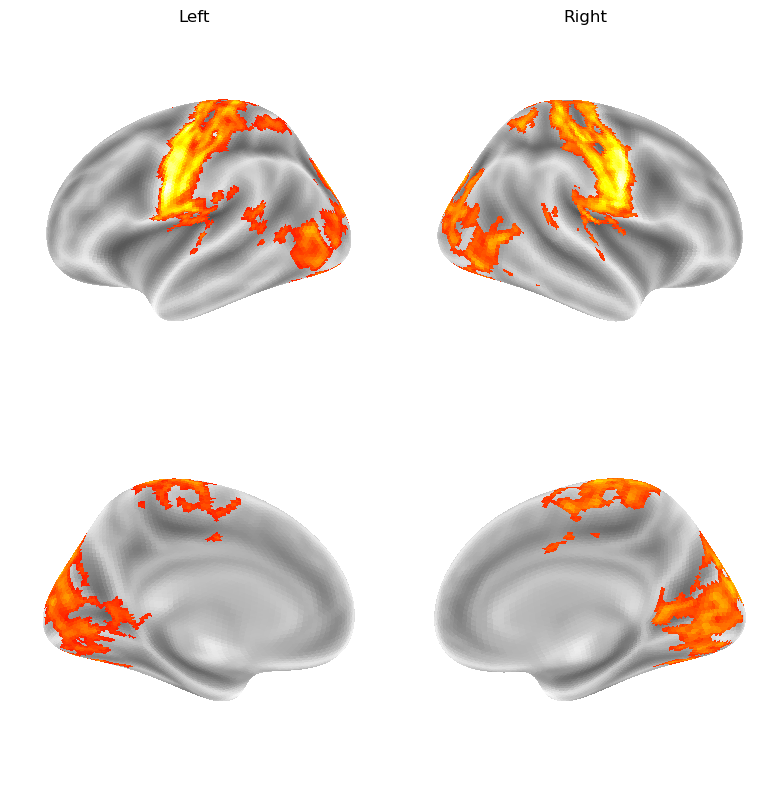

In [20]:
# Plot the FC map

av_fcmap_allsub = fcmap_allsub.mean(axis=0)
av_fcmap_p_allsub = fcmap_p_allsub.mean(axis=0)
# # threshold the Fc maps with the pvalues 
# fcmap_thresholded = np.copy(av_fcmap_allsub)
# fcmap_thresholded[np.where(av_fcmap_p_allsub>0.05)] = 0

fsaverage = datasets.fetch_surf_fsaverage()
fcmap_img = nib.Nifti1Image(av_fcmap_allsub, sub_affine)
texture_left = surface.vol_to_surf(fcmap_img, fsaverage.pial_left)
texture_right = surface.vol_to_surf(fcmap_img, fsaverage.pial_right)

thresh = 0.2 # Threshold for the brain plots

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, figsize=(8,8))
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       title='Left', view='lateral',colorbar=False, threshold=thresh, axes=axs[0][0])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                       title='Right', view='lateral', colorbar=False, threshold=thresh, axes=axs[0][1])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][0])
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][1])
plt.tight_layout()
plotting.show()

# Let's try to find the Default Mode Network

## Define the seed areas
We choose the medial frontal cortex, one of the main regions of the default mode network

In [21]:
# seed_areas = atlas_labels.loc[atlas_labels['cortex']=='Somatosensory_and_Motor']
# seed_areas = atlas_labels.loc[atlas_labels['regionLongName']=='PreCuneus_Visual_Area_L']
seed_areas_names = ['Area_10r_L','Area_10v_L', 'Area_9_Middle_L']
seed_idxs = []
for s in seed_areas_names:
    seed_areas = atlas_labels.loc[atlas_labels['regionLongName']==s]
    seed_idx = seed_areas['regionID'].values # Indexes of the seed areas
    seed_idxs.append(seed_idx[0])

In [22]:
# Make the brain mask of the seed
seeds_mask = np.zeros(atlas.shape)
for seed in seed_idxs:
    seeds_mask += (atlas==seed)

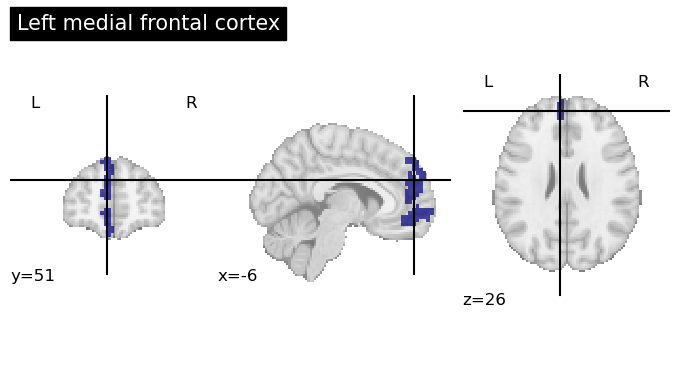

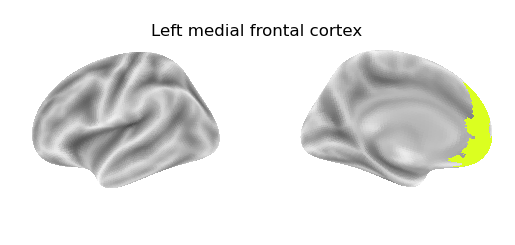

In [23]:
### Plot the seed area ###
## Plot on the volume of the brain

# Create a new image for the selected region
seeds_img = nib.Nifti1Image(seeds_mask.astype(np.int16), atlas_affine)
# Plot the selected region
plotting.plot_roi(seeds_img, display_mode='ortho', title='Left medial frontal cortex')
plotting.show()

# Plot over the surface of the brain ##
fsaverage = datasets.fetch_surf_fsaverage()
texture_left = surface.vol_to_surf(seeds_img, fsaverage.pial_left)
texture_left[np.where(texture_left!=0)] = 1

fig, axs = plt.subplots(1,2, subplot_kw={'projection': '3d'})
# left hemisphere
plotting.plot_surf_roi(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       colorbar=False, view='lateral',axes=axs[0])
plotting.plot_surf_roi(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       colorbar=False, view='medial', axes=axs[1])
fig.suptitle('Left medial frontal cortex', x=0.51, y=0.7);

In [24]:
### Signal filtering ###
sub_filtered = np.copy(sub)
TR = sub_.header.get_zooms()[3]
for v in tqdm(range(n_vox_mask)):
    voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    T = TimeSeries(voxel_ts.T, sampling_interval=TR)
    F = FilterAnalyzer(T, ub=0.08, lb=0.008) #0.08, 0.008
    tmp_TC_filt = F.filtered_boxcar.data
    tmp_TC_filt = tmp_TC_filt.T
    sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt

100%|███████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [00:08<00:00, 6255.34it/s]


In [25]:
# Extract the time series of the seed region
seed_voxels = sub_filtered[seeds_mask==1]
seed_ts = seed_voxels.mean(axis=0)

# At first, choose the coorrelation measure
corr_measure = pearsonr
# corr_measure = spearmanr

# Initialize stuff
fcmap = np.empty(mask.shape) # Initialize the functional connectivity map
fcmap_p = np.empty(mask.shape) # p-values related the correlation measure
mask_cord = np.where(mask==1) # Coordinates of all the voxel within the brain mask

## Correlation ##
# Loop over all the voxel of the brain
for v in tqdm(range(n_vox_mask)):
    voxel_ts = sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    corr = corr_measure(seed_ts, voxel_ts)
    fcmap[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[0]
    fcmap_p[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[1]

  0%|▏                                                                                          | 80/50151 [00:00<01:02, 799.33it/s]C:\Users\alebo\AppData\Local\Temp\ipykernel_13372\29738755.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = corr_measure(seed_ts, voxel_ts)
100%|███████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [00:42<00:00, 1191.25it/s]


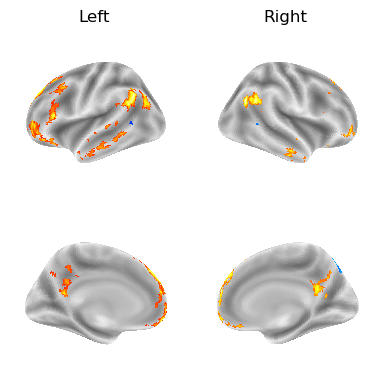

In [26]:
# threshold the Fc maps with the pvalues 
fcmap_thresholded = np.copy(fcmap)
fcmap_thresholded[np.where(fcmap_p>0.01/n_vox_mask)] = 0

fsaverage = datasets.fetch_surf_fsaverage()
fcmap_img = nib.Nifti1Image(fcmap_thresholded, sub_affine)
texture_left = surface.vol_to_surf(fcmap_img, fsaverage.pial_left)
texture_right = surface.vol_to_surf(fcmap_img, fsaverage.pial_right)

thresh = 0.35 # Threshold for the brain plots

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, figsize=(4,4))
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       title='Left', view='lateral',colorbar=False, threshold=thresh, axes=axs[0][0])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                       title='Right', view='lateral', colorbar=False, threshold=thresh, axes=axs[0][1])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][0])
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][1])
plt.tight_layout()
plotting.show()

## Let's do the analysis for all the subjects

In [27]:
main_path='C:/Unito/PhD/CorsoFisica/data/rest_STD_clean/' # Path to the folder with the subjects

# At first, choose the coorrelation measure
corr_measure = pearsonr
# corr_measure = spearmanr
mask_cord = np.where(mask==1) # Coordinates of all the voxel within the brain mask


fcmap_allsub = np.empty(mask.shape)[np.newaxis,:,:,:]
fcmap_p_allsub = np.empty(mask.shape)[np.newaxis,:,:,:]

# Loop over the subjects
for sub_file in filelist:
    print(sub_file)
    sub_ = nib.load(main_path+sub_file) # Load the nii.gz file of the subject
    sub_header = sub_.header # Subject's header
    sub_affine = sub_.affine # Subject's affine
    sub = sub_.get_fdata() # Get the numpy version of the nii.gz file
    
    # Filter the signal
    sub_filtered = np.copy(sub)
    TR = sub_.header.get_zooms()[3]
    print('Filtering the signal...')
    for v in tqdm(range(n_vox_mask)):
        voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
        T = TimeSeries(voxel_ts.T, sampling_interval=TR)
        F = FilterAnalyzer(T, ub=0.08, lb=0.008) #0.08, 0.008
        tmp_TC_filt = F.filtered_boxcar.data
        tmp_TC_filt = tmp_TC_filt.T
        sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt

    # Compute the average time series of the seed region
    seed_voxels = sub_filtered[seeds_mask==1]
    seed_ts = seed_voxels.mean(axis=0)

    fcmap = np.empty(mask.shape) # Initialize the functional connectivity map
    fcmap_p = np.empty(mask.shape) # p-values related the correlation measure

    # Loop over all the voxel of the brain
    print('Computing the correlation...')
    for v in tqdm(range(n_vox_mask)):
        voxel_ts = sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
        corr = corr_measure(seed_ts, voxel_ts)
        fcmap[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[0]
        fcmap_p[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[1]
    
    fcmap_allsub = np.concatenate((fcmap_allsub, fcmap[np.newaxis,:,:,:]))
    fcmap_p_allsub = np.concatenate((fcmap_p_allsub, fcmap_p[np.newaxis,:,:,:]))

sub-01_rest_STD.nii.gz
Filtering the signal...


100%|███████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [00:08<00:00, 5904.41it/s]


Computing the correlation...


100%|███████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [00:42<00:00, 1181.59it/s]


sub-02_rest_STD.nii.gz
Filtering the signal...


...

100%|███████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [00:41<00:00, 1217.38it/s]


sub-18_rest_STD.nii.gz
Filtering the signal...


100%|███████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [00:08<00:00, 6117.31it/s]


Computing the correlation...


100%|███████████████████████████████████████████████████████████████████████████████████████| 50151/50151 [00:43<00:00, 1154.41it/s]


C:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
C:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


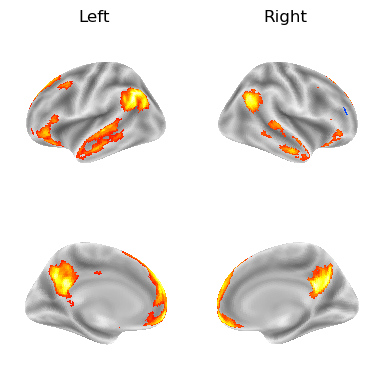

In [28]:
av_fcmap_allsub = fcmap_allsub.mean(axis=0)
av_fcmap_p_allsub = fcmap_p_allsub.mean(axis=0)
# # threshold the Fc maps with the pvalues 
# fcmap_thresholded = np.copy(av_fcmap_allsub)
# fcmap_thresholded[np.where(av_fcmap_p_allsub>0.05)] = 0

fsaverage = datasets.fetch_surf_fsaverage()
fcmap_img = nib.Nifti1Image(av_fcmap_allsub, sub_affine)
texture_left = surface.vol_to_surf(fcmap_img, fsaverage.pial_left)
texture_right = surface.vol_to_surf(fcmap_img, fsaverage.pial_right)

thresh = 0.2 # Threshold for the brain plots

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, figsize=(4,4))
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       title='Left', view='lateral',colorbar=False, threshold=thresh, axes=axs[0][0])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                       title='Right', view='lateral', colorbar=False, threshold=thresh, axes=axs[0][1])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][0])
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][1])
plt.tight_layout()
plotting.show()

# Compute the functional connectivity of the thalamus

In [ ]:
# Load the thalamus ro
path_left = 
path_right = 

# Task-evoked functional connectivity